# Capstone Two: Modeling

#### Clickstream Data for Online Shopping
#### Dataset: https://archive.ics.uci.edu/dataset/553/clickstream+data+for+online+shopping

In this notebook, we will be creating two to three machine learning models and evaluating the performance of each.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
# Import data and convert date from object type
df = pd.read_csv('dataset/shopping_data_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])

# Convert columns to object
cols_to_object = ['country', 
                        'page 1 (main category)', 
                        'page 2 (clothing model)', 
                        'colour', 
                        'location', 
                        'model photography']
df[cols_to_object] = df[cols_to_object].astype('object')
print(df.dtypes)

year                                int64
month                               int64
day                                 int64
order                               int64
country                            object
session ID                          int64
page 1 (main category)             object
page 2 (clothing model)            object
colour                             object
location                           object
model photography                  object
price                             float64
price 2                             int64
page                                int64
date                       datetime64[ns]
dtype: object


In [3]:
# Convert 'price 2' to boolean
df['price 2_bool'] = (df['price 2'] == 1)

In [4]:
# Drop extra columns
df = df.drop(columns = ['year', 'month', 'day', 'price 2'])

In [5]:
print(df.dtypes)

order                               int64
country                            object
session ID                          int64
page 1 (main category)             object
page 2 (clothing model)            object
colour                             object
location                           object
model photography                  object
price                             float64
page                                int64
date                       datetime64[ns]
price 2_bool                         bool
dtype: object


## 1. K Means

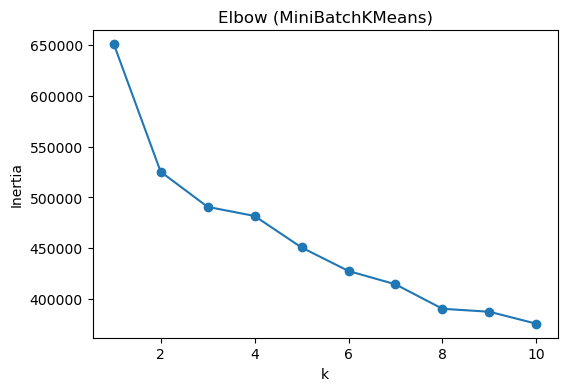

Silhouette at k=2: 0.186


In [12]:
# One-time preprocess and SVD
numeric_features     = ["price"]
categorical_features = [
    "country",
    "page 1 (main category)",
    "page 2 (clothing model)",
    "colour",
    "location",
    "model photography"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])
preprocessor.fit(df)
X_prep = preprocessor.transform(df)

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_prep)  # (n_samples × 50)

# Elbow with MiniBatchKMeans
ks = range(1, 11)
inertias = []

for k in ks:
    mbk = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=2000,    
        n_init=2,           
        max_iter=100        
    )
    mbk.fit(X_reduced)
    inertias.append(mbk.inertia_)

plt.figure(figsize=(6,4))
plt.plot(ks, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow (MiniBatchKMeans)")
plt.show()

# 
k_elbow = 2
mbk = MiniBatchKMeans(n_clusters=k_elbow, random_state=42, batch_size=2000, n_init=2, max_iter=100)
labels = mbk.fit_predict(X_reduced)

# Sample for silhouette
sample_idx = np.random.choice(X_reduced.shape[0], size=5000, replace=False)
sil = silhouette_score(X_reduced[sample_idx], labels[sample_idx])
print(f"Silhouette at k={k_elbow}: {sil:.3f}")

## Agglomerative Clustering

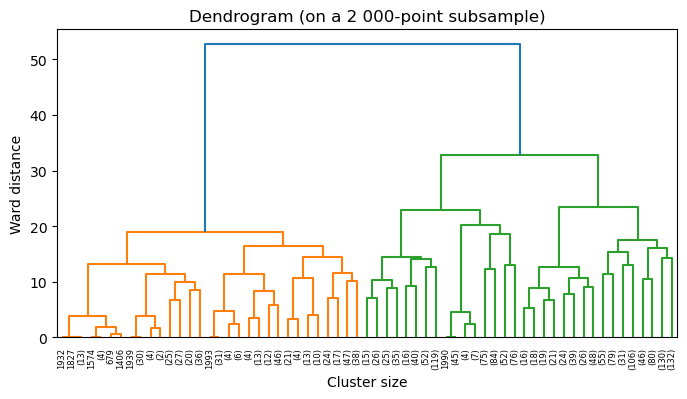

k=2 silhouette (sampled): 0.192


In [15]:
# One-time preprocess and SVD
numeric = ["price"]
cats = [
    "country",
    "page 1 (main category)",
    "page 2 (clothing model)",
    "colour",
    "location",
    "model photography"
]
pre = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cats),
])
X_prep = pre.fit_transform(df)             
X_red  = TruncatedSVD(50, random_state=42).fit_transform(X_prep)  

# Subsample for linkage and dendrogram
m = 2000
sub_idx = np.random.choice(len(X_red), size=m, replace=False)
X_sub   = X_red[sub_idx]

Z = linkage(X_sub, method="ward")
plt.figure(figsize=(8, 4))
dendrogram(Z, truncate_mode="level", p=5, show_leaf_counts=True)
plt.title("Dendrogram (on a 2 000-point subsample)")
plt.xlabel("Cluster size")
plt.ylabel("Ward distance")
plt.show()

# AgglomerativeClustering on the same subsample
k = 2  
agg_sub = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_sub = agg_sub.fit_predict(X_sub)

# Nearest-neighbor projection back to full data
nn = NearestNeighbors(n_neighbors=1).fit(X_sub)
full_idx = nn.kneighbors(X_red, return_distance=False).flatten()
labels_full = labels_sub[full_idx]

# Sampled silhouette on the full projection
sample_idx = np.random.choice(len(X_red), size=5000, replace=False)
sil = silhouette_score(X_red[sample_idx], labels_full[sample_idx])
print(f"k={k} silhouette (sampled): {sil:.3f}")

## DBSCAN

In [18]:
# Build the k-distance vector
nbrs      = NearestNeighbors(n_neighbors=5).fit(X_reduced)
distances, _ = nbrs.kneighbors(X_reduced)
d5        = np.sort(distances[:, 4])

# Find the knee by looking at the largest first difference
delta     = np.diff(d5)
knee_idx  = np.argmax(delta) + 1
eps_auto  = float(d5[knee_idx])
print(f"Auto-detected eps ≈ {eps_auto:.4f}")

# Try a more aggressive min_samples
min_samples = max(10, 2 * X_reduced.shape[1])

db = DBSCAN(eps=eps_auto, min_samples=min_samples, n_jobs=-1)
labels = db.fit_predict(X_reduced)

n_clusters = len(set(labels) - {-1})
n_noise    = (labels == -1).sum()
print(f"Clusters: {n_clusters}, Noise: {n_noise}")

# Evaluate silhouette on core points
mask = labels != -1
if n_clusters > 1 and mask.sum() > 1:
    sil = silhouette_score(X_reduced[mask], labels[mask])
    print(f"Silhouette (excl. noise): {sil:.3f}")
else:
    print("Not enough valid clusters for silhouette.")

Auto-detected eps ≈ 1.2820
Clusters: 96, Noise: 100
Silhouette (excl. noise): 0.406


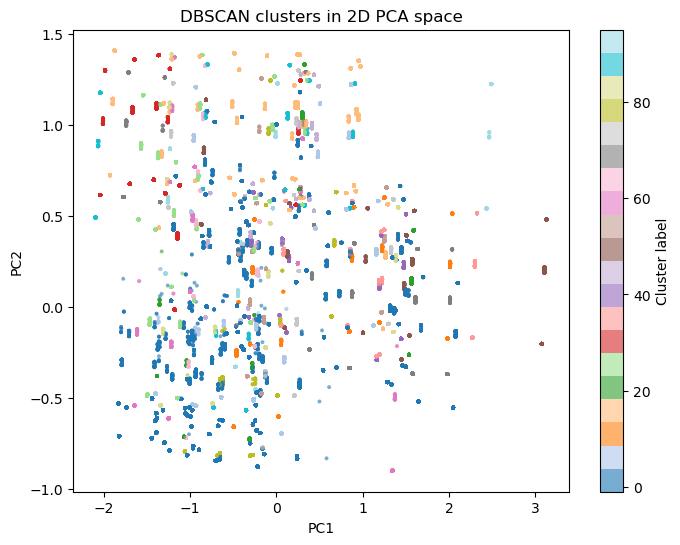

In [20]:
from sklearn.decomposition import PCA

# Project to 2D
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_reduced)

# Plot
plt.figure(figsize=(8, 6))
colors = ['gray' if lbl == -1 else lbl for lbl in labels]
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=labels,            
    cmap='tab20',        
    s=8,                 
    alpha=0.6,
    linewidth=0
)
plt.title("DBSCAN clusters in 2D PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster label")
plt.show()

In [22]:
# Examine cluster sizes
counts = pd.Series(labels, name="cluster").value_counts().sort_values()
print(counts.describe())          
print(counts[counts < 50])        

count       97.000000
mean      1705.917526
std       4406.144773
min        100.000000
25%        539.000000
50%       1118.000000
75%       1834.000000
max      43806.000000
Name: count, dtype: float64
Series([], Name: count, dtype: int64)


In [26]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
print(silhouette_score(X_2d, labels))
print(calinski_harabasz_score(X_2d, labels))

-0.21350736937270512
4234.881716818411


In [30]:
summary = df.assign(cluster=labels).groupby('cluster')
means  = summary.mean(numeric_only=True)
counts = summary.size().rename("count")

cluster_profile = means.join(counts)
print(cluster_profile)

             order    session ID      price      page  price 2_bool  count
cluster                                                                   
-1       19.640000  13471.460000  43.180000  2.000000       1.00000    100
 0       11.171324  12158.148176  41.237502  1.944619       0.45722  43806
 1        6.293657  11839.480022  52.000000  1.000000       1.00000   3579
 2        7.663006  11829.105697  38.000000  1.000000       0.00000   1457
 3        8.072519  11700.593511  52.000000  1.000000       1.00000    524
...            ...           ...        ...       ...           ...    ...
 91      11.013812  12892.254144  28.000000  2.000000       0.00000    724
 92      14.758065  10678.616129  43.000000  2.000000       1.00000    310
 93       9.562731  11734.869004  38.000000  2.000000       0.00000    542
 94      15.933333  11581.340741  43.000000  2.000000       1.00000    135
 95      19.739130  12629.239130  77.000000  3.000000       1.00000    184

[97 rows x 6 columns]


## Conclusions

#### KMeans
1. Our elbow appears between 3-4, but the silhouette score at 2 and 3 remained low indicating weak clusters.
2. K-Means resulted in large, diffuse groups that could not be clearly linked to behavioural patterns.

#### Hierarchical Clusters
1. Dendrogram does not indicate a natural "cut" height to create cohesive clusters.
2. As with K-Means, this model provides weak clusters.

#### DBSCAN
1. Our clusters ranged in size from ~100 to ~44000.
2. Our moderate silhouette still indicates no strong clustering
3. The visualization of the data shows micro-clustering, with one very large cluster that is likely all the data points that did not adhere to a micro cluster.

#### Next Steps
We would need further experimentation and modeling to find clusters that could be used to accomplish our original goals of creating segmentation for marketing purposes.  This could be achieved through experimentation with different models and hyperparameter tuning.